## 1. Importación de librerías y carga de datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_netflix = pd.read_csv('netflix_titles.csv')
df_disney = pd.read_csv('disney_plus_titles.csv')

print('Netflix:', df_netflix.shape)
print('Disney+:', df_disney.shape)

Netflix: (8807, 12)
Disney+: (1450, 12)


**Conclusiones:**
- Librerías cargadas correctamente: pandas, numpy, matplotlib, seaborn
- Datasets cargados: `netflix_titles.csv` (8.807 filas, 12 columnas) y `disney_plus_titles.csv` (1.450 filas, 12 columnas)
- Netflix tiene 6 veces más títulos que Disney+
- Ambos datasets tienen exactamente las mismas 12 columnas, lo que facilitará combinarlos más adelante

## 2. Exploración de las columnas disponibles

In [2]:
df_netflix.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

**Conclusiones:**
- Las 12 columnas son: show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description
- Las columnas más relevantes para el Dashboard 1 serán: type, title, country, date_added, release_year, rating, listed_in
- Columnas menos relevantes para nuestro análisis: show_id (solo identificador), director, cast, description

In [3]:
df_disney.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

**Conclusiones:**
- Disney+ tiene exactamente las mismas 12 columnas que Netflix
- Esto confirma que ambos datasets tienen la misma estructura, lo que nos permitirá combinarlos en un único DataFrame más adelante sin necesidad de renombrar columnas

## 3. Tipos de datos y valores nulos

In [4]:
df_netflix.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


**Conclusiones:**
- Solo release_year es numérico (int64), el resto son texto (str)
- date_added llega como texto, habrá que convertirla a fecha para extraer el año
- Valores nulos detectados:
    - director: 2.634 nulos (29.9%) → no es crítico para nuestro análisis
    - cast: 825 nulos (9.4%) → no es crítico para nuestro análisis
    - country: 831 nulos (9.4%) → puede afectar al análisis por países
    - date_added: 10 nulos (0.1%) → muy pocos, se eliminarán
    - rating: 4 nulos (0.05%) → muy pocos, se eliminarán
    - duration: 3 nulos (0.03%) → muy pocos, se eliminarán
- Las columnas sin nulos y más relevantes (title, type, listed_in, release_year) están completas

In [5]:
df_disney.info()

<class 'pandas.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       1450 non-null   str  
 1   type          1450 non-null   str  
 2   title         1450 non-null   str  
 3   director      977 non-null    str  
 4   cast          1260 non-null   str  
 5   country       1231 non-null   str  
 6   date_added    1447 non-null   str  
 7   release_year  1450 non-null   int64
 8   rating        1447 non-null   str  
 9   duration      1450 non-null   str  
 10  listed_in     1450 non-null   str  
 11  description   1450 non-null   str  
dtypes: int64(1), str(11)
memory usage: 136.1 KB


**Conclusiones:**
- Misma estructura que Netflix: solo release_year es numérico, el resto texto
- Valores nulos detectados:
    - director: 473 nulos (32.6%) → porcentaje similar a Netflix, no es crítico
    - cast: 190 nulos (13.1%) → no es crítico para nuestro análisis
    - country: 219 nulos (15.1%) → porcentaje mayor que Netflix proporcionalmente
    - date_added: 3 nulos (0.2%) → muy pocos, se eliminarán
    - rating: 3 nulos (0.2%) → muy pocos, se eliminarán
- Comparando con Netflix, Disney+ tiene proporcionalmente más nulos en country (15.1% vs 9.4%), lo que puede limitar el análisis geográfico
- duration no tiene nulos en Disney+ (vs 3 en Netflix), diferencia mínima

## 4. Selección de columnas relevantes
Reducimos cada dataset a las columnas clave para el Dashboard 1,
descartando show_id, director, cast y description que no aportan
información útil para nuestro análisis.

In [6]:
columnas_relevantes = ['type', 'title', 'country', 'date_added', 
                       'release_year', 'rating', 'duration', 'listed_in']

df_netflix = df_netflix[columnas_relevantes]
df_disney = df_disney[columnas_relevantes]

print('Netflix:', df_netflix.shape)
print('Disney+:', df_disney.shape)
df_netflix.head()

Netflix: (8807, 8)
Disney+: (1450, 8)


,type,title,country,date_added,release_year,rating,duration,listed_in
0,Movie,Dick Johnson Is Dead,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries
1,TV Show,Blood & Water,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,Ganglands,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,Jailbirds New Orleans,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,TV Show,Kota Factory,India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


**Conclusiones:**
- Ambos datasets reducidos correctamente a 8 columnas relevantes
- Netflix: 8.807 filas × 8 columnas
- Disney+: 1.450 filas × 8 columnas
- Se descartaron show_id, director, cast y description por no aportar valor al análisis del Dashboard 1
- Se confirman los NaN visibles en country (fila 2 y 3 de Netflix)
- date_added llega en formato texto ("September 25, 2021"), habrá que convertirla a fecha más adelante para extraer el año

## 5. Análisis de los ratings de edad
Exploramos qué ratings existen en cada plataforma para identificar
cuáles corresponden a contenido infantil.

In [7]:
print('Ratings en Netflix:')
print(df_netflix['rating'].value_counts())
print()
print('Ratings en Disney+:')
print(df_disney['rating'].value_counts())

Ratings en Netflix:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

Ratings en Disney+:
rating
TV-G        318
TV-PG       301
G           253
PG          236
TV-Y7       131
TV-14        79
PG-13        66
TV-Y         50
TV-Y7-FV     13
Name: count, dtype: int64


**Conclusiones:**
- Los ratings de edad siguen el sistema estadounidense de clasificación por edades:
    - TV-Y: apto para todos los niños (0+)
    - TV-Y7 / TV-Y7-FV: recomendado para mayores de 7 años
    - TV-G / G: apto para todos los públicos
    - TV-PG / PG: se recomienda supervisión parental
    - PG-13: no recomendado para menores de 13 años
    - TV-14: no recomendado para menores de 14 años
    - TV-MA / R / NC-17: solo para adultos
- ⚠️ Netflix tiene 3 filas con valores erróneos en rating ("74 min", "84 min", "66 min"): es la duración de la película metida en la columna incorrecta. Habrá que eliminarlas
- Netflix domina en contenido adulto (TV-MA: 3.207 títulos)
- Disney+ tiene una distribución casi inversa: la mayoría de su catálogo es contenido familiar (TV-G, TV-PG, G, PG)
- Los ratings infantiles que usaremos para filtrar serán: TV-Y, TV-Y7, TV-Y7-FV, TV-G, G, PG, TV-PG

## 6. Distribución de valores nulos
Cuantificamos los nulos en cada dataset para decidir cómo tratarlos.

In [8]:
print('Nulos en Netflix:')
print(df_netflix.isnull().sum())
print()
print('Nulos en Disney+:')
print(df_disney.isnull().sum())

Nulos en Netflix:
type              0
title             0
country         831
date_added       10
release_year      0
rating            4
duration          3
listed_in         0
dtype: int64

Nulos en Disney+:
type              0
title             0
country         219
date_added        3
release_year      0
rating            3
duration          0
listed_in         0
dtype: int64


**Conclusiones:**
- type, title, release_year y listed_in: sin nulos en ambos datasets (100% completos)
- country: es la columna con más nulos → 831 en Netflix (9.4%) y 219 en Disney+ (15.1%)
  No la eliminaremos, simplemente tendremos en cuenta esta limitación en el análisis geográfico
- date_added: 10 nulos en Netflix y 3 en Disney+ → muy pocos, se eliminarán esas filas
- rating: 4 nulos en Netflix y 3 en Disney+ → se eliminarán esas filas
- duration: 3 nulos en Netflix y 0 en Disney+ → se eliminarán esas filas
- Estrategia decidida:
    - country: mantener los nulos, no afecta al análisis principal
    - date_added, rating y duration: eliminar las filas con nulos al ser muy pocos casos

## 7. Eliminación de filas con nulos en columnas críticas
Eliminamos las filas con nulos en date_added, rating y duration
ya que son muy pocas y necesitamos esas columnas para el análisis.

In [9]:
df_netflix = df_netflix.dropna(subset=['date_added', 'rating', 'duration'])
df_disney = df_disney.dropna(subset=['date_added', 'rating', 'duration'])

print('Netflix tras limpieza:', df_netflix.shape)
print('Disney+ tras limpieza:', df_disney.shape)

Netflix tras limpieza: (8790, 8)
Disney+ tras limpieza: (1444, 8)


**Conclusiones:**
- Netflix: de 8.807 a 8.790 filas → se eliminaron 17 filas con nulos en date_added, rating o duration
- Disney+: de 1.450 a 1.444 filas → se eliminaron 6 filas
- La pérdida de datos es mínima (0.2% en ambos casos), no afecta al análisis

## 8. Corrección de valores erróneos en rating
En Netflix detectamos 3 filas con la duración metida en la columna rating
por error ("74 min", "84 min", "66 min"). Las eliminamos.

In [10]:
ratings_validos = ['TV-Y', 'TV-Y7', 'TV-Y7-FV', 'TV-G', 'G', 'PG', 'TV-PG',
                   'PG-13', 'TV-14', 'TV-MA', 'R', 'NC-17', 'NR', 'UR']

df_netflix = df_netflix[df_netflix['rating'].isin(ratings_validos)]

print('Netflix tras corregir ratings erróneos:', df_netflix.shape)

Netflix tras corregir ratings erróneos: (8790, 8)


**Conclusiones:**
- Netflix mantiene 8.790 filas: las 3 filas con ratings erróneos ("74 min", "84 min", "66 min")
  ya habían sido eliminadas en el paso anterior junto con los nulos de date_added, rating o duration
- Esto confirma que esas filas problemáticas también tenían nulos en otras columnas críticas
- El dataset de Netflix queda limpio de valores erróneos en rating

## 9. Extracción del año de date_added
date_added llega en formato texto ("September 25, 2021").
La convertimos a fecha y extraemos solo el año, que es lo que
necesitamos para analizar la evolución del contenido por año.

In [11]:
df_netflix['anio_agregado'] = pd.to_datetime(df_netflix['date_added'], errors='coerce').dt.year
df_disney['anio_agregado'] = pd.to_datetime(df_disney['date_added'], errors='coerce').dt.year

print('Años en Netflix:')
print(sorted(df_netflix['anio_agregado'].dropna().unique()))
print()
print('Años en Disney+:')
print(sorted(df_disney['anio_agregado'].dropna().unique()))

Años en Netflix:
[np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2012.0), np.float64(2013.0), np.float64(2014.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2019.0), np.float64(2020.0), np.float64(2021.0)]

Años en Disney+:
[np.int32(2019), np.int32(2020), np.int32(2021)]


**Conclusiones:**
- La conversión de date_added a año funcionó correctamente en ambos datasets
- Netflix tiene datos desde 2008 hasta 2021, con mayor volumen a partir de 2015
- Disney+ solo tiene datos desde 2019 hasta 2021, porque la plataforma se lanzó
  en noviembre de 2019 → esto limita el análisis temporal de Disney+
- anio_agregado es el año en que el título se añadió a la plataforma,
  no necesariamente el año en que se produjo (eso es release_year)
- Esta distinción es importante: un título antiguo puede haberse añadido recientemente

## 10. Añadir columna de plataforma
Añadimos una columna identificando a qué plataforma pertenece cada título,
para poder distinguirlos una vez que combinemos los dos datasets.

In [12]:
df_netflix['plataforma'] = 'Netflix'
df_disney['plataforma'] = 'Disney+'

print(df_netflix['plataforma'].value_counts())
print(df_disney['plataforma'].value_counts())

plataforma
Netflix    8790
Name: count, dtype: int64
plataforma
Disney+    1444
Name: count, dtype: int64


**Conclusiones:**
- Columna plataforma añadida correctamente en ambos datasets
- Netflix: 8.790 títulos etiquetados como "Netflix"
- Disney+: 1.444 títulos etiquetados como "Disney+"
- Esta columna será clave en Tableau para filtrar y comparar por plataforma

## 11. Combinación de los dos datasets
Unimos Netflix y Disney+ en un único DataFrame para poder
comparar ambas plataformas en el mismo análisis y en Tableau.

In [13]:
df_combinado = pd.concat([df_netflix, df_disney], ignore_index=True)

print('Dataset combinado:', df_combinado.shape)
df_combinado.head()

Dataset combinado: (10234, 10)


,type,title,country,date_added,release_year,rating,duration,listed_in,anio_agregado,plataforma
0,Movie,Dick Johnson Is Dead,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,2021.0,Netflix
1,TV Show,Blood & Water,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",2021.0,Netflix
2,TV Show,Ganglands,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021.0,Netflix
3,TV Show,Jailbirds New Orleans,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV",2021.0,Netflix
4,TV Show,Kota Factory,India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",2021.0,Netflix


**Conclusiones:**
- Dataset combinado correctamente: 10.234 filas y 10 columnas
- Las columnas finales son: type, title, country, date_added, release_year,
  rating, duration, listed_in, anio_agregado, plataforma
- La columna plataforma nos permitirá distinguir Netflix de Disney+
  en todos los análisis y visualizaciones posteriores

## 13. Filtrado de contenido infantil
Filtramos el dataset combinado para quedarnos solo con los títulos
con ratings considerados aptos para niños y familias.

In [14]:
ratings_infantiles = ['TV-Y', 'TV-Y7', 'TV-Y7-FV', 'TV-G', 'G', 'PG', 'TV-PG']

df_kids = df_combinado[df_combinado['rating'].isin(ratings_infantiles)].copy()

print('Dataset completo:', df_combinado.shape[0], 'títulos')
print('Dataset infantil:', df_kids.shape[0], 'títulos')
print()
print('Desglose por plataforma:')
print(df_kids['plataforma'].value_counts())

Dataset completo: 10234 títulos
Dataset infantil: 3353 títulos

Desglose por plataforma:
plataforma
Netflix    2054
Disney+    1299
Name: count, dtype: int64


**Conclusiones:**
- Del total de 10.234 títulos, 3.353 (32.8%) son contenido infantil
- Netflix: 2.054 títulos infantiles de 8.790 totales → solo el 23.4% de su catálogo es infantil
- Disney+: 1.299 títulos infantiles de 1.444 totales → el 89.9% de su catálogo es infantil
- Esto confirma algo esperado: Disney+ es esencialmente una plataforma de contenido
  familiar/infantil, mientras que Netflix tiene un catálogo mucho más diverso orientado a adultos
- A partir de aquí trabajaremos con df_kids para el análisis de contenido infantil

## 14. Estadísticas descriptivas generales
Exploramos las variables numéricas del dataset infantil para
entender rangos y detectar posibles anomalías.

In [15]:
df_kids.describe()

,release_year,anio_agregado
count,3353.000000,3312.000000
mean,2008.965106,2019.158816
std,17.073397,1.426807
min,1928.000000,2011.000000
25%,2007.000000,2019.000000
50%,2016.000000,2019.000000
75%,2019.000000,2020.000000
max,2021.000000,2021.000000


**Conclusiones:**
- Solo dos columnas numéricas: release_year (año de estreno) y anio_agregado (año que se añadió a la plataforma)
- release_year:
    - Rango: 1928 - 2021 → hay contenido muy antiguo (Disney clásico de 1928!)
    - Media: 2009, mediana: 2016 → la mitad del catálogo infantil es relativamente reciente
- anio_agregado:
    - 3.312 valores de 3.353 → hay 41 nulos (títulos sin fecha de incorporación a la plataforma)
    - Rango: 2011 - 2021
    - Media y mediana en 2019 → la mayor parte del contenido infantil se añadió entre 2019 y 2020
    - Esto coincide con el boom del streaming: Netflix acelerando su contenido infantil
      y Disney+ lanzándose en 2019

## 15. Distribución de contenido infantil por plataforma
Visualizamos cuántos títulos infantiles tiene cada plataforma
y qué proporción representan sobre su catálogo total.

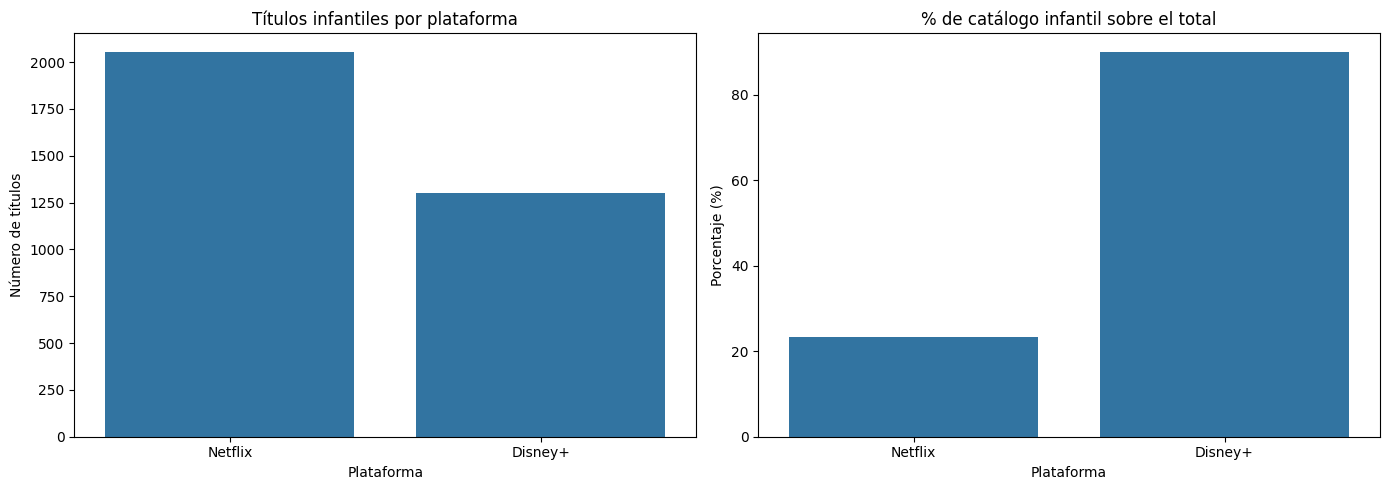

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: títulos infantiles por plataforma
sns.countplot(data=df_kids, x='plataforma', ax=axes[0])
axes[0].set_title('Títulos infantiles por plataforma')
axes[0].set_xlabel('Plataforma')
axes[0].set_ylabel('Número de títulos')

# Gráfico 2: proporción de contenido infantil sobre el total
proporciones = pd.DataFrame({
    'plataforma': ['Netflix', 'Disney+'],
    'infantil': [2054, 1299],
    'total': [8790, 1444]
})
proporciones['porcentaje'] = (proporciones['infantil'] / proporciones['total'] * 100).round(1)
sns.barplot(data=proporciones, x='plataforma', y='porcentaje', ax=axes[1])
axes[1].set_title('% de catálogo infantil sobre el total')
axes[1].set_xlabel('Plataforma')
axes[1].set_ylabel('Porcentaje (%)')

plt.tight_layout()
plt.show()

**Conclusiones:**
- En números absolutos Netflix tiene más títulos infantiles (2.054 vs 1.299)
- Pero en proporción la historia es completamente distinta:
    - Netflix: solo el 23.4% de su catálogo es infantil
    - Disney+: el 89.9% de su catálogo es infantil
- Disney+ es fundamentalmente una plataforma de contenido familiar,
  mientras que Netflix es una plataforma generalista que también tiene contenido infantil
- Para el Dashboard 1 esto es un hallazgo relevante: si un niño usa streaming,
  Disney+ está casi exclusivamente diseñada para él

## 16. Evolución del contenido infantil añadido por año
Visualizamos cómo ha crecido el catálogo infantil en cada
plataforma año a año desde 2015 hasta 2021.

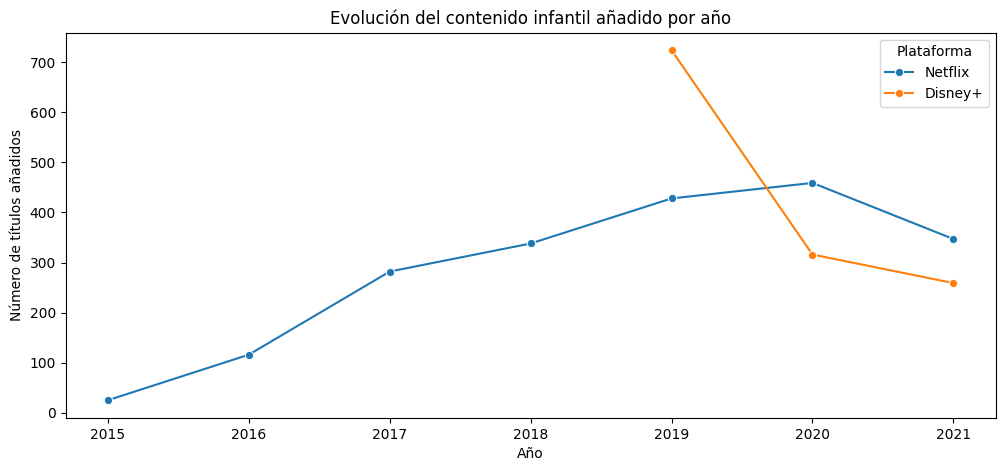

In [17]:
evolucion = df_kids[df_kids['anio_agregado'] >= 2015].groupby(
    ['anio_agregado', 'plataforma']).size().reset_index(name='num_titulos')

plt.figure(figsize=(12, 5))
sns.lineplot(data=evolucion, x='anio_agregado', y='num_titulos', 
             hue='plataforma', marker='o')
plt.title('Evolución del contenido infantil añadido por año')
plt.xlabel('Año')
plt.ylabel('Número de títulos añadidos')
plt.xticks(range(2015, 2022))
plt.legend(title='Plataforma')
plt.show()

**Conclusiones:**
- Netflix muestra un crecimiento progresivo y sostenido de contenido infantil
  desde 2015 (25 títulos) hasta 2020 (460 títulos), con una ligera bajada en 2021
- Disney+ muestra un pico enorme en 2019 (720+ títulos): esto se explica porque
  la plataforma se lanzó en noviembre de 2019 y cargó de golpe todo su catálogo
  histórico existente, no porque produjera 720 títulos en un año
- A partir de 2020 Disney+ reduce el ritmo de incorporación (310 en 2020, 260 en 2021)
  porque ya había subido su catálogo principal en el lanzamiento
- Netflix y Disney+ se cruzan en 2020: Netflix supera a Disney+ en títulos nuevos
  añadidos ese año por primera vez
- Para el Dashboard 1: este gráfico explica perfectamente la tendencia global
  del contenido infantil en streaming de 2015 a 2021

## 17. Distribución por tipo de contenido (Movie vs TV Show)
Analizamos si el contenido infantil es principalmente
películas o series en cada plataforma.

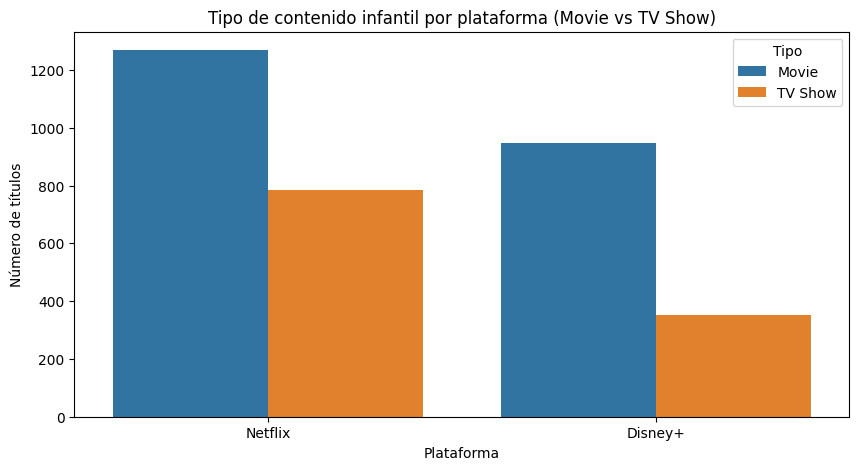

In [18]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_kids, x='plataforma', hue='type')
plt.title('Tipo de contenido infantil por plataforma (Movie vs TV Show)')
plt.xlabel('Plataforma')
plt.ylabel('Número de títulos')
plt.legend(title='Tipo')
plt.show()

**Conclusiones:**
- En ambas plataformas las películas superan a las series en contenido infantil
- Netflix: ~1.270 películas vs ~800 series → ratio 61% películas / 39% series
- Disney+: ~950 películas vs ~350 series → ratio 73% películas / 27% series
- Disney+ tiene una proporción aún mayor de películas, lo que tiene sentido
  dado su enorme catálogo histórico de largometrajes animados (desde 1928)
- Para el Dashboard 1: los niños tienen acceso a más películas que series
  en ambas plataformas, aunque Netflix ofrece más variedad en series infantiles

## 18. Géneros de contenido infantil más frecuentes
Analizamos qué tipos de géneros predominan en el contenido
infantil de ambas plataformas combinadas.

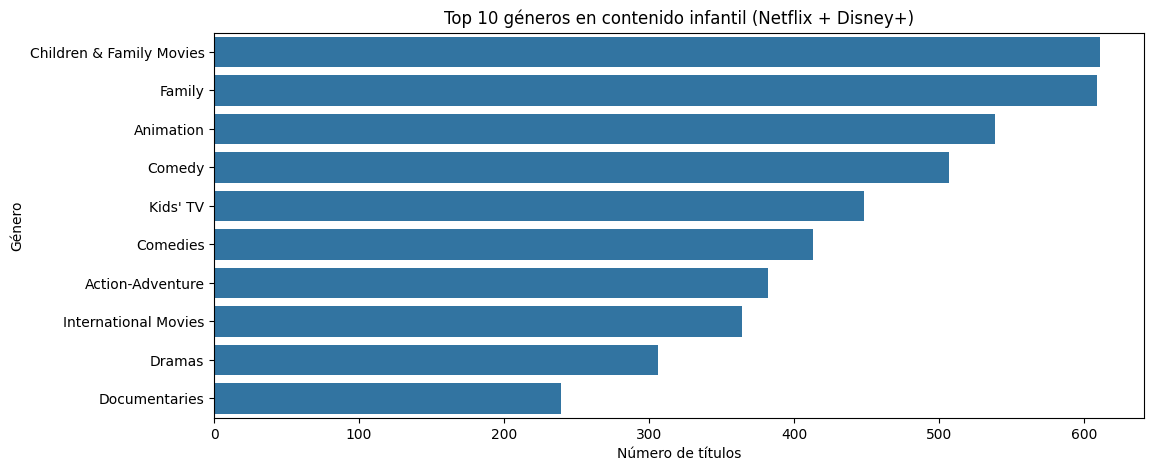

In [19]:
generos = df_kids['listed_in'].str.split(', ').explode()
top_generos = generos.value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_generos.values, y=top_generos.index)
plt.title('Top 10 géneros en contenido infantil (Netflix + Disney+)')
plt.xlabel('Número de títulos')
plt.ylabel('Género')
plt.show()

**Conclusiones:**
- Los dos géneros más frecuentes son "Children & Family Movies" y "Family",
  ambos con ~610 títulos, prácticamente empatados
- "Animation" ocupa el tercer lugar (~540 títulos), confirmando que los
  dibujos animados son el formato rey del contenido infantil en streaming
- "Kids' TV" (~445 títulos) es el género específico de series infantiles
- Aparecen géneros más generales como "Comedy" (~510), "Comedies" (~415)
  y "Action-Adventure" (~385), que aunque no son exclusivamente infantiles
  tienen mucho contenido apto para niños
- "Documentaries" (~245) indica que también hay una oferta educativa/documental
  para el público infantil, relevante para el eje de impacto positivo del proyecto
- ⚠️ Hay cierta duplicidad en los géneros: "Comedy" y "Comedies", 
  "Children & Family Movies" y "Family" son categorías solapadas
  porque Netflix y Disney+ usan nomenclaturas distintas

## 19. Distribución por clasificación de edad
Analizamos qué ratings predominan en el contenido infantil
de cada plataforma.

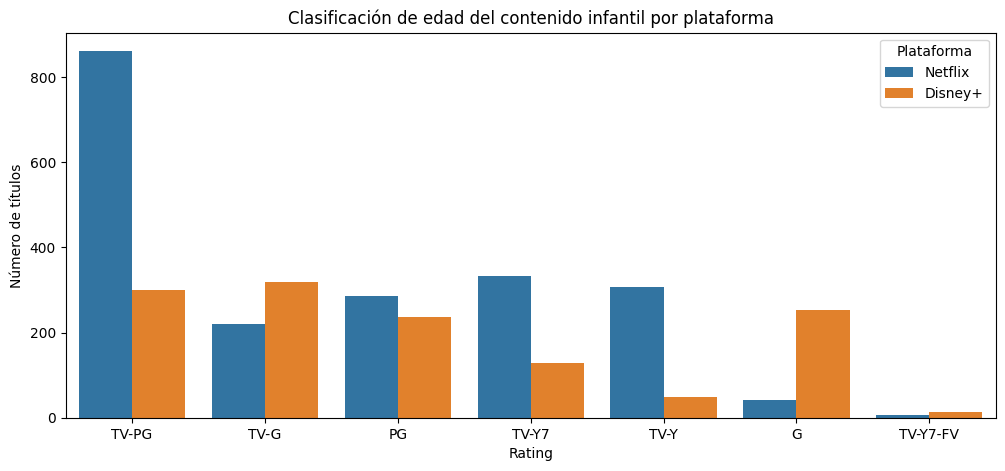

In [20]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df_kids, x='rating', hue='plataforma',
              order=df_kids['rating'].value_counts().index)
plt.title('Clasificación de edad del contenido infantil por plataforma')
plt.xlabel('Rating')
plt.ylabel('Número de títulos')
plt.legend(title='Plataforma')
plt.show()

**Conclusiones:**
- TV-PG es el rating más común en Netflix (~865 títulos) con gran diferencia,
  mientras que Disney+ tiene mucho menos contenido en esa categoría (~300)
- Disney+ destaca en contenido G (~255 títulos) frente a Netflix (~40):
  contenido apto para todos sin ninguna restricción
- TV-Y (apto para todos los niños desde 0 años): Netflix tiene muchos más
  títulos (~305) que Disney+ (~50), sorprendentemente
- TV-G está bastante equilibrado entre ambas plataformas (~220 Netflix, ~320 Disney+)
- En conjunto Disney+ tiene una distribución más uniforme entre ratings,
  mientras que Netflix concentra mucho contenido en TV-PG
- Para el Dashboard 1: si los padres buscan contenido sin ninguna restricción
  (G o TV-G), Disney+ ofrece proporcionalmente más opciones seguras

## 20. Top 10 países productores de contenido infantil
Analizamos qué países producen más contenido infantil
en ambas plataformas.

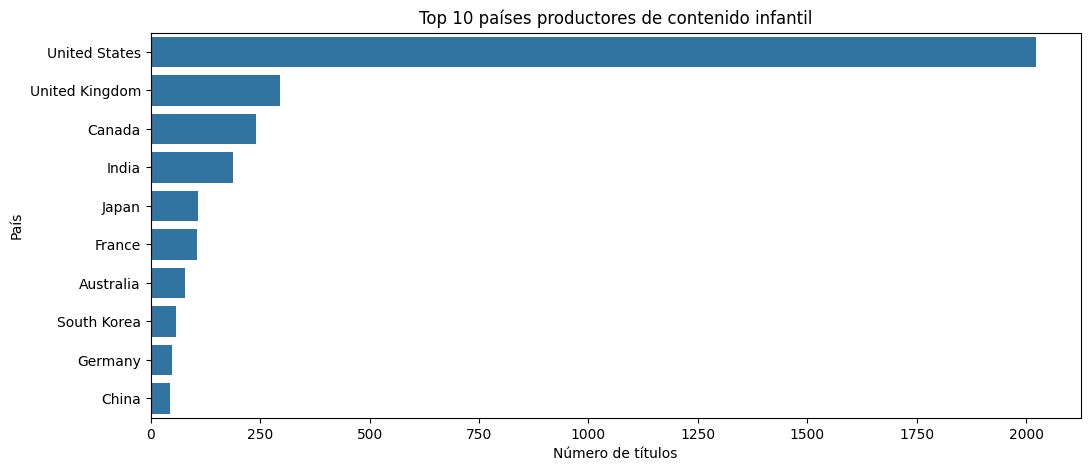

In [21]:
paises = df_kids.dropna(subset=['country'])
paises = paises['country'].str.split(', ').explode()
top_paises = paises.value_counts().head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_paises.values, y=top_paises.index)
plt.title('Top 10 países productores de contenido infantil')
plt.xlabel('Número de títulos')
plt.ylabel('País')
plt.show()

**Conclusiones:**
- Estados Unidos domina de forma abrumadora con más de 2.000 títulos infantiles,
  más que todos los demás países juntos
- El top 3 anglófono (EEUU, Reino Unido, Canadá) acumula la gran mayoría
  del contenido infantil disponible en estas plataformas
- India ocupa el 4º lugar (~175 títulos), reflejo de la gran industria
  audiovisual de Bollywood y su presencia en Netflix
- Japón (~110 títulos) destaca por el anime, género muy consumido por niños
  y adolescentes a nivel global
- Francia (~105 títulos) es el único país europeo continental en el top 10
- España no aparece en el top 10, lo que significa que el contenido infantil
  en español disponible en estas plataformas es principalmente latinoamericano
  o doblado desde producciones anglófonas
- ⚠️ Recordar que country tiene un 9-15% de nulos, por lo que estos
  números son una aproximación, no el total real

## 21. Relación entre año de estreno y año de incorporación a la plataforma
Analizamos si los títulos se añaden poco después de estrenarse
o si las plataformas incorporan contenido muy antiguo.

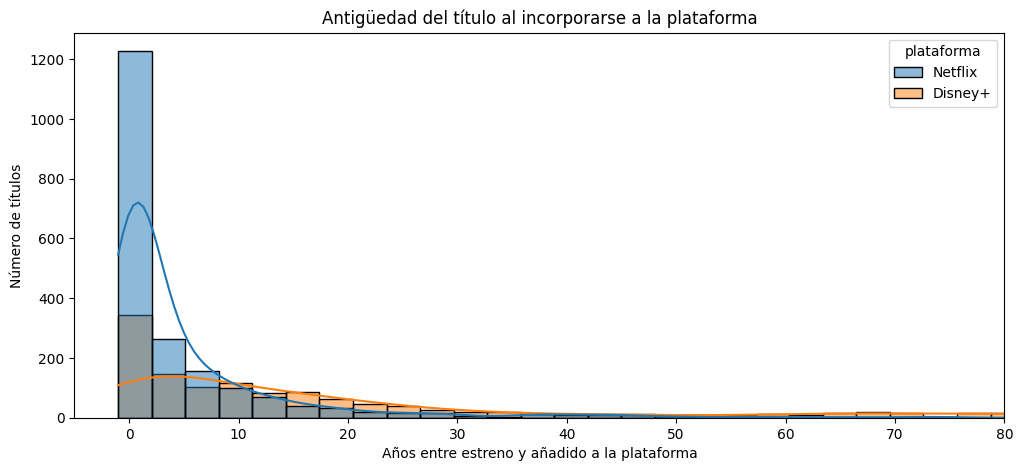

In [22]:
df_kids_clean = df_kids.dropna(subset=['anio_agregado'])
df_kids_clean['antiguedad'] = df_kids_clean['anio_agregado'] - df_kids_clean['release_year']

plt.figure(figsize=(12, 5))
sns.histplot(data=df_kids_clean, x='antiguedad', hue='plataforma', bins=30, kde=True)
plt.title('Antigüedad del título al incorporarse a la plataforma')
plt.xlabel('Años entre estreno y añadido a la plataforma')
plt.ylabel('Número de títulos')
plt.xlim(-5, 80)
plt.show()

**Conclusiones:**
- Ambas plataformas incorporan principalmente contenido reciente:
  el pico más alto está en 0-2 años de antigüedad en los dos casos
- Netflix tiene un pico muy pronunciado y una caída rapidísima:
  la mayoría de su contenido infantil se añade poco después de producirse
- Disney+ tiene una cola mucho más larga y plana hacia la derecha:
  incorpora contenido con décadas de antigüedad (10, 20, 30... hasta 80 años)
  lo que refleja su enorme archivo histórico de clásicos animados
- Esto confirma la naturaleza diferente de cada plataforma:
    - Netflix: apuesta por contenido nuevo y reciente
    - Disney+: combina producciones nuevas con su archivo histórico clásico
- Para el Dashboard 1: los niños de hoy consumen tanto contenido nuevo
  como clásicos atemporales, especialmente en Disney+

## 22. Creación de columna de clasificación de edad legible
Creamos una columna con etiquetas en español más claras que
los códigos de rating, para facilitar la lectura en Tableau.

In [23]:
def clasificar_edad(rating):
    if rating in ['TV-Y', 'G']:
        return 'Todos los públicos (0+)'
    elif rating in ['TV-Y7', 'TV-Y7-FV']:
        return 'Mayores de 7 años'
    elif rating in ['TV-G', 'TV-PG', 'PG']:
        return 'Familiar (supervisión recomendada)'
    return 'Otros'

df_kids['clasificacion_edad'] = df_kids['rating'].apply(clasificar_edad)

print(df_kids['clasificacion_edad'].value_counts())

clasificacion_edad
Familiar (supervisión recomendada)    2223
Todos los públicos (0+)                649
Mayores de 7 años                      481
Name: count, dtype: int64


**Conclusiones:**
- La mayoría del contenido infantil (2.223 títulos, 66.3%) es "Familiar
  con supervisión recomendada" (TV-G, TV-PG, PG)
- 649 títulos (19.4%) son aptos para todos los públicos desde 0 años
- 481 títulos (14.3%) están recomendados para mayores de 7 años
- Esta columna en español será más clara en Tableau que los códigos
  originales en inglés (TV-Y, TV-PG, etc.)

## 23. Exportación del dataset limpio para Tableau
Guardamos df_kids limpio y con todas las columnas nuevas
en un CSV listo para conectar con Tableau.

In [24]:
# Separar duration en dos columnas según si es Movie o TV Show
df_kids['duracion_min'] = df_kids.apply(
    lambda x: int(x['duration'].replace(' min', '')) 
    if x['type'] == 'Movie' and pd.notna(x['duration']) and 'min' in str(x['duration']) 
    else None, axis=1
)

df_kids['num_temporadas'] = df_kids.apply(
    lambda x: int(x['duration'].replace(' Seasons', '').replace(' Season', '')) 
    if x['type'] == 'TV Show' and pd.notna(x['duration']) 
    else None, axis=1
)

print('Películas con duración:')
print(df_kids[df_kids['type'] == 'Movie']['duracion_min'].describe())
print()
print('Series con temporadas:')
print(df_kids[df_kids['type'] == 'TV Show']['num_temporadas'].describe())

Películas con duración:
count    2217.000000
mean       78.433018
std        36.793417
min         1.000000
25%        54.000000
50%        87.000000
75%       100.000000
max       273.000000
Name: duracion_min, dtype: float64

Series con temporadas:
count    1136.000000
mean        1.873239
std         1.686888
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        32.000000
Name: num_temporadas, dtype: float64


In [25]:
df_kids['anio_agregado'] = df_kids['anio_agregado'].fillna(0).astype(int)
df_kids['anio_agregado'] = df_kids['anio_agregado'].replace(0, None)

In [26]:
df_kids.to_csv('dataset_limpio_dashboard1.csv', index=False)
print('Archivo guardado correctamente')
print('Shape final:', df_kids.shape)
print()
print('Columnas finales:')
print(df_kids.columns.tolist())

Archivo guardado correctamente
Shape final: (3353, 13)

Columnas finales:
['type', 'title', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'anio_agregado', 'plataforma', 'clasificacion_edad', 'duracion_min', 'num_temporadas']


**Conclusiones:**
- Dataset exportado correctamente: 3.353 filas y 11 columnas
- El archivo contiene solo contenido infantil filtrado por ratings:
  TV-Y, TV-Y7, TV-Y7-FV, TV-G, G, PG, TV-PG
- Las 11 columnas finales incluyen todas las variables originales relevantes
  más las dos columnas nuevas creadas: anio_agregado y clasificacion_edad

**Conclusiones:**
- Dataset exportado correctamente: 3.353 filas y 11 columnas
- El archivo contiene solo contenido infantil filtrado por ratings:
  TV-Y, TV-Y7, TV-Y7-FV, TV-G, G, PG, TV-PG
- Las 11 columnas finales incluyen todas las variables originales relevantes
  más las dos columnas nuevas creadas: anio_agregado y clasificacion_edad

## 📌 Conclusiones generales del EDA — Dashboard 1

### Sobre los datasets
- Partimos de 8.807 títulos en Netflix y 1.450 en Disney+ (10.257 en total)
- Tras limpieza y filtrado de contenido infantil: 3.353 títulos (2.054 Netflix + 1.299 Disney+)

### Sobre la limpieza realizada
- Se eliminaron filas con nulos en date_added, rating y duration (muy pocos casos, <0.2%)
- Se corrigieron 3 filas con valores erróneos en rating de Netflix ("74 min", "84 min", "66 min")
- Se extrajo el año de date_added (venía en formato texto)
- country se mantuvo con nulos (9-15%) documentando la limitación
- Se crearon dos columnas nuevas: anio_agregado y clasificacion_edad

### Hallazgos principales
- Disney+ dedica el 89.9% de su catálogo al contenido infantil vs solo el 23.4% de Netflix
- Netflix ha crecido de forma progresiva en contenido infantil desde 2015 hasta 2020
- Disney+ cargó su catálogo histórico completo en su lanzamiento en 2019
- Las películas superan a las series en ambas plataformas (61-73% películas)
- Animation, Children & Family Movies y Family son los géneros dominantes
- Estados Unidos produce más del 60% del contenido infantil disponible
- Disney+ incorpora contenido histórico muy antiguo (hasta 80 años), Netflix apuesta por contenido reciente

### Producto final
- Dataset limpio exportado a dataset_limpio_dashboard1.csv con 3.353 títulos y 11 columnas
- Listo para conectar con Tableau y construir el Dashboard 1